<a href="https://colab.research.google.com/github/suryamanoj4/SMAI-Assignment-3/blob/main/SMAI_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Census Income Prediction with Random Forests

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib

username = "manoj.pentakota"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
print(seed)

2817696157


In [2]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

data = pd.read_csv("/content/adult.data",header=None,names=columns,skipinitialspace=True,na_values="?")
print(f"no of row: {data.shape[0]}")
print(f"no of columns: {data.shape[1]}")

print("\n data head")
display(data.head())

print("\n data info")
display(data.info())

no of row: 32561
no of columns: 15

 data head


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



 data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


None

In [3]:
dtype_summary = pd.DataFrame({
    "features": data.columns,
    "dtype": data.dtypes.astype(str).values,
    "non null": data.notna().sum().values,
    "missing": data.isna().sum().values
})

print(dtype_summary)

          features   dtype  non null  missing
0              age   int64     32561        0
1        workclass  object     30725     1836
2           fnlwgt   int64     32561        0
3        education  object     32561        0
4    education-num   int64     32561        0
5   marital-status  object     32561        0
6       occupation  object     30718     1843
7     relationship  object     32561        0
8             race  object     32561        0
9              sex  object     32561        0
10    capital-gain   int64     32561        0
11    capital-loss   int64     32561        0
12  hours-per-week   int64     32561        0
13  native-country  object     31978      583
14          income  object     32561        0


In [4]:
numerical_features = data.select_dtypes(include=np.number).columns.tolist()
categorical_features = data.select_dtypes(include="object").columns.tolist()

target = "income"

feature_columns=[column for column in data.columns if column != target]
print("\nfeature columns:", feature_columns)

categorical_features.remove(target)
print("\nnumerical features:", numerical_features)
print("\ncategorical features:", categorical_features)


feature columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

numerical features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [5]:
categorical_summary = pd.DataFrame({
    "feature": categorical_features,
    "unique": [data[column].nunique(dropna=True) for column in categorical_features],
})

display(categorical_summary)

for column in categorical_features:
    print(f"\n{column}")
    print(data[column].value_counts(dropna=False))

numerical_summary = data[numerical_features].describe().T
display(numerical_summary)

,feature,unique
0,workclass,8
1,education,16
2,marital-status,7
3,occupation,14
4,relationship,6
5,race,5
6,sex,2
7,native-country,41



workclass
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
NaN                  1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

education
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

marital-status
marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

occupation
occupation
Prof-specialty       41

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education-num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital-gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital-loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours-per-week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [6]:
missing_summary = pd.DataFrame({
    "feature": data.columns,
    "missing": data.isna().sum().values
})

display(missing_summary[missing_summary["missing"] > 0])

,feature,missing
1,workclass,1836
6,occupation,1843
13,native-country,583


In [7]:
target_counts = data[target].value_counts()
target_distribution = pd.DataFrame({
    "class": target_counts.index,
    "count": target_counts.values,
    "proportion": target_counts.values/len(data)
})

display(target_distribution)

,class,count,proportion
0,<=50K,24720,0.75919
1,>50K,7841,0.24081


In [8]:
# redundant features

correlation_matrix=data[numerical_features].corr(method="pearson")
display(correlation_matrix)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education-num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital-gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital-loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours-per-week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


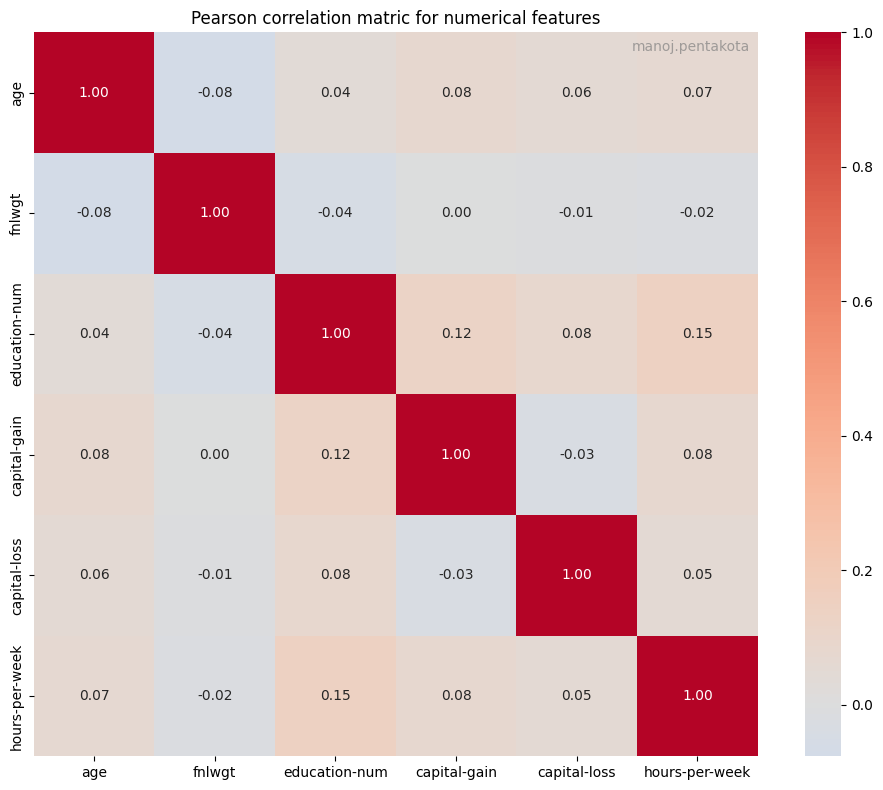

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Pearson correlation matric for numerical features")
plt.text(0.99,0.99,"manoj.pentakota",
         ha='right',va='top',
         transform=plt.gca().transAxes,
         fontsize=10,color='gray',alpha=0.7)
plt.tight_layout()
plt.show()

from the above pearson correlation matrix for the numerical features. no pair of features has shown particularly strong correlation but ffnlwgt feature had a particularly weak correation comparitive to other numerical features.

In [11]:
redundant_features = ["fnlwgt"]
data=data.drop(columns=redundant_features)

print("remaining no of features:", data.shape[1])

remaining no of features: 14


In [12]:
# train val test split

from sklearn.model_selection import train_test_split

x=data.drop(columns=["income"])
y=data["income"]

x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=seed,stratify=y)

adult_test = pd.read_csv(
    "/content/adult.test",
    header=None,
    names=columns,
    skipinitialspace=True,
    na_values="?",
    skiprows=1
)

# remove the previous redundant feature
adult_test=adult_test.drop(columns=redundant_features)

#remove the "." for the test set income labels
adult_test["income"]=adult_test["income"].str.replace(".","")

x_test=adult_test.drop(columns=["income"])
y_test=adult_test["income"]

print(f"training: {x_train.shape[0]}")
print(f"validation: {x_val.shape[0]}")
print(f"test: {x_test.shape[0]}")

training: 26048
validation: 6513
test: 16281


In [13]:
def class_distribution(y, split_name):
  counts= y.value_counts()
  proportions = y.value_counts(normalize=True)*100

  return pd.DataFrame({
      "split": split_name,
      "class": counts.index,
      "count": counts.values,
      "proportion": proportions.values
  })

split_distribution = pd.concat([
    class_distribution(y_train, "train"),
    class_distribution(y_val, "validation"),
    class_distribution(y_test, "test")
], ignore_index=True)

display(split_distribution)

,split,class,count,proportion
0,train,<=50K,19775,75.917537
1,train,>50K,6273,24.082463
2,validation,<=50K,4945,75.925073
3,validation,>50K,1568,24.074927
4,test,<=50K,12435,76.377372
5,test,>50K,3846,23.622628


In [15]:
"""
fill the missing values
for numerical features -> median
for categorical features -> mode

for numerical features median is choosen as modian is less sensitive to outliers
and for categorical mode represents the most frequently appeared label
"""
if "fnlwgt" in numerical_features:
  numerical_features.remove("fnlwgt")
numerical_imputation_values = {feature: x_train[feature].median() for feature in numerical_features}
categorical_imputation_values = {feature: x_train[feature].mode()[0] for feature in categorical_features}

for feature in numerical_features:
  x_train[feature] = x_train[feature].fillna(numerical_imputation_values[feature])
  x_val[feature] = x_val[feature].fillna(numerical_imputation_values[feature])
  x_test[feature] = x_test[feature].fillna(numerical_imputation_values[feature])

for feature in categorical_features:
  x_train[feature] = x_train[feature].fillna(categorical_imputation_values[feature])
  x_val[feature] = x_val[feature].fillna(categorical_imputation_values[feature])
  x_test[feature] = x_test[feature].fillna(categorical_imputation_values[feature])


print("training missing values")
display(x_train.isna().sum().sum())

print("\nvalidation missing values")
display(x_val.isna().sum().sum())

print("\ntest missing values")
display(x_test.isna().sum().sum())

training missing values


np.int64(0)


validation missing values


np.int64(0)


test missing values


np.int64(0)

In [16]:
#categorical encoding

category_mapping={}
for feature in categorical_features:
  category_mapping[feature]=sorted(x_train[feature].unique())

for feature, categories in category_mapping.items():
  print(f"{feature}:")
  print(categories)
  print()

workclass:
['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']

education:
['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college']

marital-status:
['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']

occupation:
['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']

relationship:
['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']

race:
['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']

sex:
['Female', 'Male']

native-country:
['Cambodia', 'Canada', 'China', 'Columbia', 'Cuba', 'Domi

In [19]:
def one_hot_encode(
    df, numerical_features, categorical_features, category_mapping):
  encoded_df = df[numerical_features].copy()
  for feature in categorical_features:
    categories = category_mapping[feature]
    for category in categories:
      column_name = f"{feature}_{category}"
      encoded_df[column_name] = (df[feature]==category).astype(int)
  return encoded_df

In [20]:
x_train_encoded = one_hot_encode(x_train,numerical_features,categorical_features,category_mapping)
x_val_encoded = one_hot_encode(x_val,numerical_features,categorical_features,category_mapping)
x_test_encoded = one_hot_encode(x_test,numerical_features,categorical_features,category_mapping)

print(f"training: {x_train_encoded.shape}")
print(f"validation: {x_val_encoded.shape}")
print(f"test: {x_test_encoded.shape}")

print(f"final no of features after preprocessing: {x_train_encoded.shape[1]}")

training: (26048, 103)
validation: (6513, 103)
test: (16281, 103)
final no of features after preprocessing: 103


In [21]:
def gini_impurity(y):
    if len(y) == 0:
        return 0.0

    _, counts = np.unique(y, return_counts=True)
    probabilities = counts/len(y)

    return 1.0 - np.sum(probabilities**2)

def entropy(y):
    if len(y) == 0:
        return 0.0

    _, counts = np.unique(y, return_counts=True)
    probabilities = counts/len(y)
    probabilities = probabilities[probabilities > 0]

    return -np.sum(probabilities*np.log2(probabilities))

def information_gain(y_parent, y_left, y_right):
    n = len(y_parent)
    n_left = len(y_left)
    n_right = len(y_right)

    if n == 0 or n_left == 0 or n_right == 0:
        return 0.0

    parent_entropy = entropy(y_parent)
    weighted_children = (n_left/n)*entropy(y_left) + (n_right/n)*entropy(y_right)

    return parent_entropy - weighted_children


class TreeNode:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, prediction=None, class_counts=None):
        self.feature_index = feature_index
        self.threshold = threshold

        self.left = left
        self.right = right

        self.prediction = prediction # Non-None value of prediction means this is a leaf.

        self.class_counts = class_counts

    def is_leaf(self):
        return self.prediction is not None

class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1, criterion="gini", max_features=None, random_state=None):

        if criterion not in ("gini", "entropy"):
            raise ValueError("criterion must be 'gini' or 'entropy'")

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.criterion = criterion
        self.max_features = max_features
        self.random_state = random_state

        self.root = None

        self.n_features_ = None
        self.n_classes_ = None
        self.classes_ = None

        self.n_leaves_ = 0
        self.max_depth_ = 0

        self.feature_importances_ = None

        self.rng = np.random.default_rng(seed)


    def fit(self, X, y):
        x = np.array(X)
        y = np.array(y)

        self.n_features_ = x.shape[1]
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)

        self.n_leaves_ = 0
        self.max_depth_ = 0

        self.feature_importances_raw = np.zeros(self.n_features_,dtype=float)
        self.root = self._build_tree(x, y, depth=0)

        #normalize the feature importance
        total_importance = np.sum(self._feature_importances_raw)
        if total_importance > 0:
          self.feature_importances_ = self._feature_importances_raw/total_importance
        else:
          self.feature_importances_ = np.zeros(self.n_features_, dtype=float)

        return self

    def predict(self, X):
        x = np.asarray(X)
        predictions = []
        for row in x:
          node=self.root
          while not node.is_leaf():
            if(row[node.feature_index]<=node.threshold):
              node=node.left
            else:
              node=node.right
          predictions.append(node.prediction)
        return np.asarray(predictions)

    def predict_proba(self, X):
        x = np.asarray(X)
        probabilities = []
        for row in x:
          node=self.root
          while not node.is_leaf():
            if(row[node.feature_index]<=node.threshold):
              node=node.left
            else:
              node=node.right
          counts = np.array([node.class_counts.get(cls,0)for cls in self.classes_],dtype=float)
          total = np.sum(counts)
          if total > 0:
            counts/=total
          probabilities.append(counts)
        return np.asarray(probabilities)

    # =========================================================
    # TREE CONSTRUCTION
    # =========================================================

    def _build_tree(self, X, y, depth):
        # 1. Check stopping conditions
        if self._should_stop(y,depth):
          return self._make_leaf(y)
        # 2. Select candidate features
        feature_indices = self._select_features(self.n_features_)
        # 3. Find best split
        best_feature,best_threshold,best_gain=self._find_best_split(X,y,feature_indices)
        if best_feature is None:
          return self._make_leaf(y)

        #split the observations
        left_mask = X[:,best_feature]<=best_threshold
        right_mask = ~left_mask
        x_left = X[left_mask]
        x_right = X[right_mask]
        y_left = y[left_mask]
        y_right = y[right_mask]

        if len(y_left)<self.min_samples_leaf or len(y_right)<self.min_samples_leaf:
          return self._make_leaf(y)

        # 4. Record impurity reduction
        n = len(y)
        parent_impurity = self._impurity(y)
        child_impurity = (len(y_left)/n)*self._impurity(y_left) + (len(y_right)/n)*self._impurity(y_right)
        impurity_reduction = parent_impurity - child_impurity
        self._feature_importance_raw[best_feature] += n*impurity_reduction
        # 5. Recursively construct children
        left_child = self._build_tree(x_left,y_left,depth+1)
        right_child = self._build_tree(x_right,y_right,depth+1)
        self.max_depth_ = max(self.max_depth_,depth)

        return TreeNode(feature_index=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    # =========================================================
    # STOPPING CONDITIONS
    # =========================================================

    def _should_stop(self, y, depth):
        if len(y)==0:
          return True
        if len(np.unique(y))==1:
          return True
        if (self.max_depth is not None and depth>=self.max_depth):
          return True
        if len(y)<self.min_samples_split:
          return True
        if len(y)<2*self.min_samples_leaf:
          return True
        return False

    # =========================================================
    # LEAF
    # =========================================================

    def _make_leaf(self, y):
        classes, counts = np.unique(y,return_counts=True)
        class_counts = dict(zip(classes,counts))
        prediction = classes[np.argmax(counts)]
        self.n_leaves_ += 1
        return TreeNode(prediction=prediction, class_counts=class_counts)
    # =========================================================
    # IMPURITY
    # =========================================================

    def _impurity(self, y):
        if self.criterion == "gini":
            return gini_impurity(y)

        return entropy(y)

    # =========================================================
    # FEATURE SELECTION
    # =========================================================

    def _select_features(self, n_features):
        if self.max_features is None:
          return np.arange(n_features)
        if isinstance(self.max_features,(int,np.integer)):
          m = int(self.max_features)
        elif isinstance(self.max_features,(float,np.floating)):
          m = int(self.max_features*n_features)
        elif isinstance(self.max_features,str):
          if self.max_features == "sqrt":
            m=int(np.sqrt(n_features))
          elif self.max_features == "log2":
            m = int(np.log2(n_features))
          else:
            raise ValueError("unsupported max_features value")
        else:
          raise ValueError("invalid max_features")

        m = max(1,m)
        m = min(n_features,m)

        return self.rng.choice(n_features,size=m,replace=False)

    # =========================================================
    # SPLIT
    # =========================================================

    def _find_best_split(self, X, y, feature_indices):
        best_feature = None
        best_threshold = None
        best_gain = -np.inf

        n=len(y)
        if n ==0:
          return None, None, 0.0
        parent_immunity = self._impurity(y)
        for feature_index in feature_indices:
          feature_values = X[:,feature_index]
          unique_values = np.unique(feature_values)
          if len(unique_values)<=1:
            continue
          threshols = (unique_values[:-1]+unique_values[1:])/2
          for threshold in threshols:
            left_mask=(feature_values<=threshold)
            right_mask=~left_mask

            n_left = np.sum(left_mask)
            n_right = np.sum(right_mask)
            if n_left == 0 or n_right ==0:
              continue
            if n_left<self.min_samples_leaf or n_right<self.min_samples_leaf:
              continue
            y_left=y[left_mask]
            y_right=y[right_mask]
            weighted_child_impurity = (n_left/n)*self._impurity(y_left) + (n_right/n)*self._impurity(y_right)
            gain = parent_immunity - weighted_child_impurity
            if gain>best_gain:
              best_feature = feature_index
              best_threshold = threshold
              best_gain = gain
        if best_feature is None:
          return None, None, 0.0
        return best_feature, best_threshold, best_gain


class RandomForest:
    def __init__(self, n_estimators, max_features, max_depth=None, min_samples_split=2, min_samples_leaf=1, criterion="gini", bootstrap=True, random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.criterion = criterion
        self.bootstrap = bootstrap
        self.random_state = random_state

        self.trees = []
        self.oob_indices = []

        self.classes_ = None
        self.n_classes_ = None
        self.n_features_ = None

        self.oob_predictions_ = None
        self.oob_score_ = None

        self.feature_importances_ = None

        self.rng = np.random.default_rng(seed)

    def fit(self, X, y):
        x = np.asarray(X)
        y = np.asarray(y)
        if n.ndim!=2:
          raise ValueError("X must be 2D")
        if len(x)!=len(y):
          raise ValueError("X and y must have the same length")

        self.n_features_ = x.shape[1]
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        self.trees = []
        self.oob_indices = []

        n_samples = len(x)
        for _ in range(self.n_estimators):
          if self.bootstrap:
            sample_indices=self.rng.choice(n_samples,size=n_samples,replace=True)
            selected=np.zeros(n_samples,dtype=bool)
            selected[sample_indices]=True
            oob_indices=np.where(~selected)[0]
          else:
            sample_indices=np.arange(n_samples)
            oob_indices=np.array([],dtype=int)
          x_bootstrap = x[sample_indices]
          y_bootstrap = y[sample_indices]
          tree_seed=int(self.rng.integers(0,2**32-1))
          tree = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split, min_samples_leaf=self.min_samples_leaf, criterion=self.criterion, max_features=self.max_features, random_state=tree_seed)
          tree.fit(x_bootstrap,y_bootstrap)
          self.trees.append(tree)
          self.oob_indices.append(oob_indices)

        if self.bootstrap:
          self._compute_oob_predictions(x,y)
          self._aggregate_feature_importance()
        return self

    def predict(self, X):
        x=np.asarray(X)
        tree_predictions=np.array([tree.predict(x) for tree in self.trees])
        predictions = []
        for sample_index in range(x.shape[0]):
          votes=tree_predictions[:,sample_index]
          classes, count = np.unique(votes,return_counts=True)
          predictions.append(classes[np.argmax(count)])
        return np.asarray(predictions)

    def predict_proba(self, X):
        x=np.asarray(X)
        tree_probabilities=np.array([tree.predict_proba(x) for tree in self.trees])
        probabilities = np.mean(tree_probabilities,axis=0)
        return probabilities

    # =========================================================
    # OOB
    # =========================================================

    def _compute_oob_predictions(self, X, y):
        n_samples = len(X)
        oob_votes=[[] for _ in range(n_samples)]
        for tree, oob_indices in zip(self.trees,self.oob_indices):
          if len(oob_indices)==0:
            continue
          predictions = tree.predict(X[oob_indices])
          for index,prediction in zip(oob_indices,predictions):
            oob_votes[index].append(prediction)
        oob_predictions = np.empty(n_samples,dtype=object)
        oob_predictions[:]=None
        valid_mask=np.zeros(n_samples,dtype=bool)
        for i in range(n_samples):
          if len(oob_votes[i])==0:
            continue
          classes,counts = np.unique(oob_votes[i],return_counts=True)
          oob_predictions[i]=(classes[np.argmax(counts)])
          valid_mask[i]=True
        self.oob_predictions_ = oob_predictions
        if np.any(valid_mask):
          self.oob_score_ = np.mean(oob_predictions[valid_mask]==y[valid_mask])
        else:
          self.oob_score_ = np.nan
        self.oob_valid_mask_ = valid_mask
        self.oob_tree_counts_ = np.array([len(votes) for votes in oob_votes])

    # =========================================================
    # FEATURE IMPORTANCE
    # =========================================================

    def _aggregate_feature_importance(self):
        if len(self.trees)==0:
          self.feature_importances_ = None
          return
        tree_importances = np.array([tree.feature_importance_ for tree in self.trees])
        mean_importance = np.mean(tree_importances,axis=0)
        total = np.sum(mean_importance)
        if total > 0:
          mean_importance/=total
        self.feature_importances_ = mean_importance

    def impurity_feature_importance(self):
        return self.feature_importances_

    # =========================================================
    # PERMUTATION IMPORTANCE
    # =========================================================

    def permutation_importance(self, X, y, n_repeats):
        x=np.asarray(X)
        y=np.asarray(y)
        baseline_predictions = self.predict(x)
        baseline_accuracy=np.mean(baseline_predictions==y)
        n_features=x.shape[1]
        importance_scores=np.zeros((n_repeats,n_features))
        for repeat in range(n_repeats):
          for feature_index in range(n_features):
            x_permuted=x.copy()
            shuffled=x_permuted[:,feature_index].copy()
            self.rng.shuffled(shuffled)
            x_permuted[:,feature_index]=shuffled
            permuted_predictions=self.predict(x_permuted)
            permuted_accuracy=np.mean(permuted_predictions==y)
            importance_scores[repeat,feature_index]=(baseline_accuracy-permuted_accuracy)
        return {
            "baseline_accuracy":baseline_accuracy,
            "importances":np.mean(importance_scores,axis=0),
            "std":np.std(importance_scores,axis=0)
        }